In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:

df = pd.read_csv('Twitter_Data.csv')


print("Dataset Shape: ", df.shape)
print("\nColumn Names: ", df.columns.tolist())
print("\nFirst 5 rows: ")
df.head()

Dataset Shape:  (162980, 2)

Column Names:  ['clean_text', 'category']

First 5 rows: 


,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


In [48]:
print("Sentiment Distribution")
print(df['category'].value_counts().sort_index())

Sentiment Distribution
category
-1.0    35510
 0.0    55213
 1.0    72250
Name: count, dtype: int64


In [ ]:

df['category'] = df['category'].map({-1.0: 'negative', 0.0: 'neutral', 1.0: 'positive'})

print(df['category'].value_counts())

category
positive    72250
neutral     55213
negative    35510
Name: count, dtype: int64


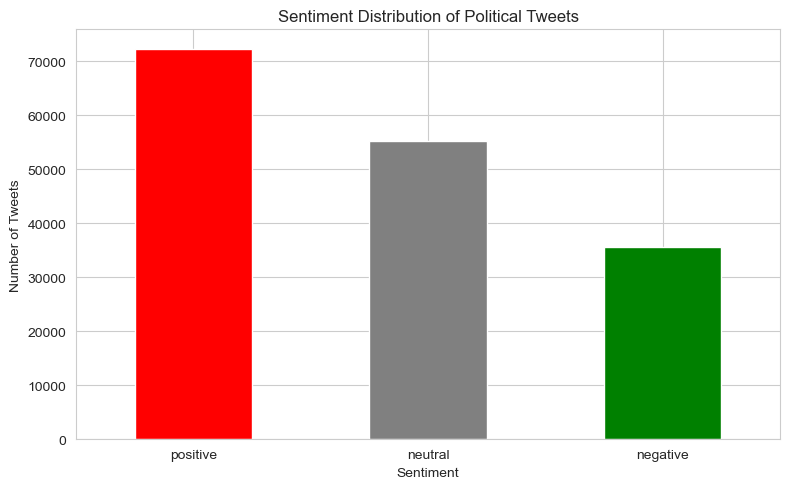

In [ ]:

plt.figure(figsize = (8, 5))
df['category'].value_counts().plot(kind = 'bar', color = ['red', 'gray', 'green'])

plt.title('Sentiment Distribution of Political Tweets')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [51]:
np.random.seed(42)
sample_size = 20000
df_sample = df.sample(n = sample_size, random_state = 42)

print(f"Working with {len(df_sample)} tweets")
print(df_sample['category'].value_counts())

Working with 20000 tweets
category
positive    8841
neutral     6749
negative    4410
Name: count, dtype: int64


In [ ]:


for sentiment in ['negative', 'neutral', 'positive']:
    print('\n' + '='*50)
    print('SAMPLE ' + sentiment.upper() + ' TWEETS:')
    print('='*50)
    samples = df_sample[df_sample['category'] == sentiment]['clean_text'].head(3)
    for i, tweet in enumerate(samples, 1):
        if len(tweet) > 200:
            print('\n' + str(i) + '. ' + tweet[:200] + '...')
        else:
            print('\n' + str(i) + '. ' + tweet)


SAMPLE NEGATIVE TWEETS:

1. story gujarat when modi was its the year 2003when was denied minimum pay for his job
such ppl are now prefixing word their names without realizing how much hard work and responsibility even this job r...

2. cant the give credit2nehru for yesterdays asat missile test afterall was who foresaw that modi would become 2014 and would need election time gimmick2return2power and inspired his descendants ensure t...

3. basic difference between modi and other party modi always tak 130 corers indians and other are only says dalits muslims minorities why are you always add peoples cast mayawati are only think about dal...

SAMPLE NEUTRAL TWEETS:

1. sir also staunch modi supporter but you should give credit our drdo scientists also

2. aloo factory productions 

3. indian modi plans national broadcast wednesday


SAMPLE POSITIVE TWEETS:

1. because they are pigs who were born raised lutyens poop they have been habituated eating sweet liberal tatti bcoz they cant dige

In [ ]:

df_sample['word_count'] = df_sample['clean_text'].apply(lambda x: len(str(x).split()))


print("Average word count per sentiment:")
print(df_sample.groupby('category')['word_count'].mean().round(2))


print("\nOverall word count stats:")
print(df_sample['word_count'].describe().round(2))

Average word count per sentiment:
category
negative    24.12
neutral     14.22
positive    22.66
Name: word_count, dtype: float64

Overall word count stats:
count    20000.00
mean        20.13
std         10.90
min          1.00
25%         11.00
50%         19.00
75%         29.00
max         50.00
Name: word_count, dtype: float64


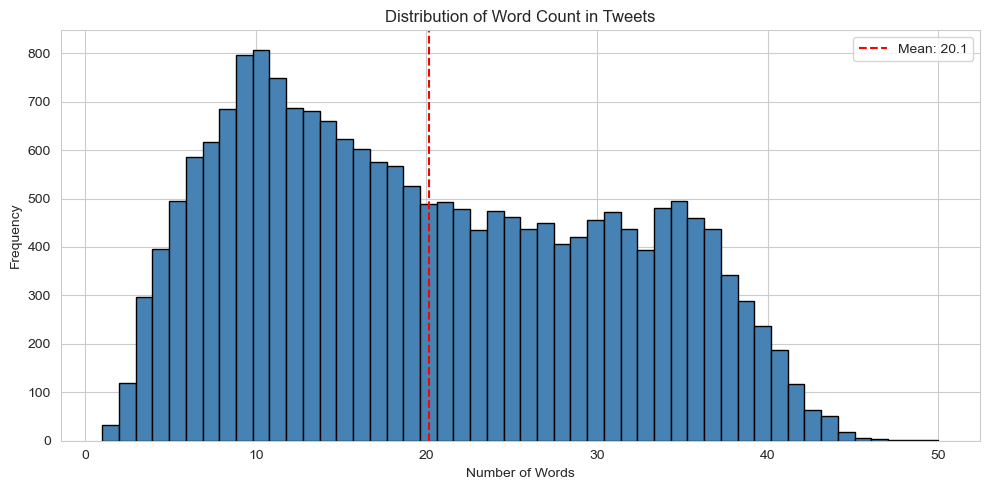

In [ ]:

plt.figure(figsize=(10, 5))
plt.hist(df_sample['word_count'], bins=50, edgecolor='black', color='steelblue')
plt.title('Distribution of Word Count in Tweets')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df_sample['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df_sample["word_count"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

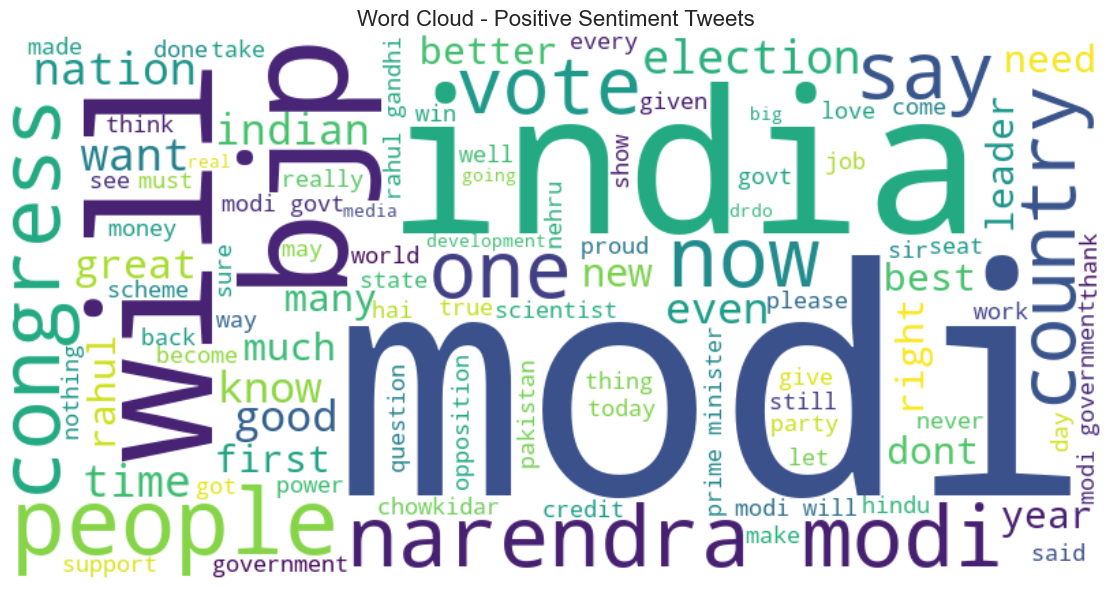

In [ ]:

positive_text = ' '.join(df_sample[df_sample['category'] == 'positive']['clean_text'].astype(str))
wc_positive = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_positive, interpolation='bilinear')
plt.title('Word Cloud - Positive Sentiment Tweets', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

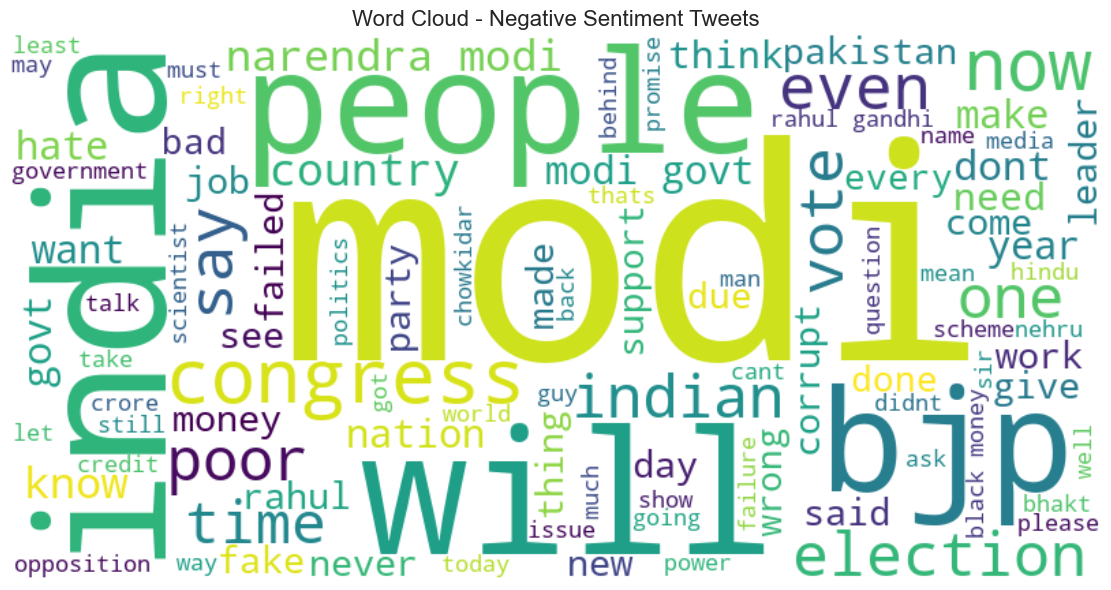

In [ ]:

negative_text = ' '.join(df_sample[df_sample['category'] == 'negative']['clean_text'].astype(str))
wc_negative = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_negative, interpolation='bilinear')
plt.title('Word Cloud - Negative Sentiment Tweets', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

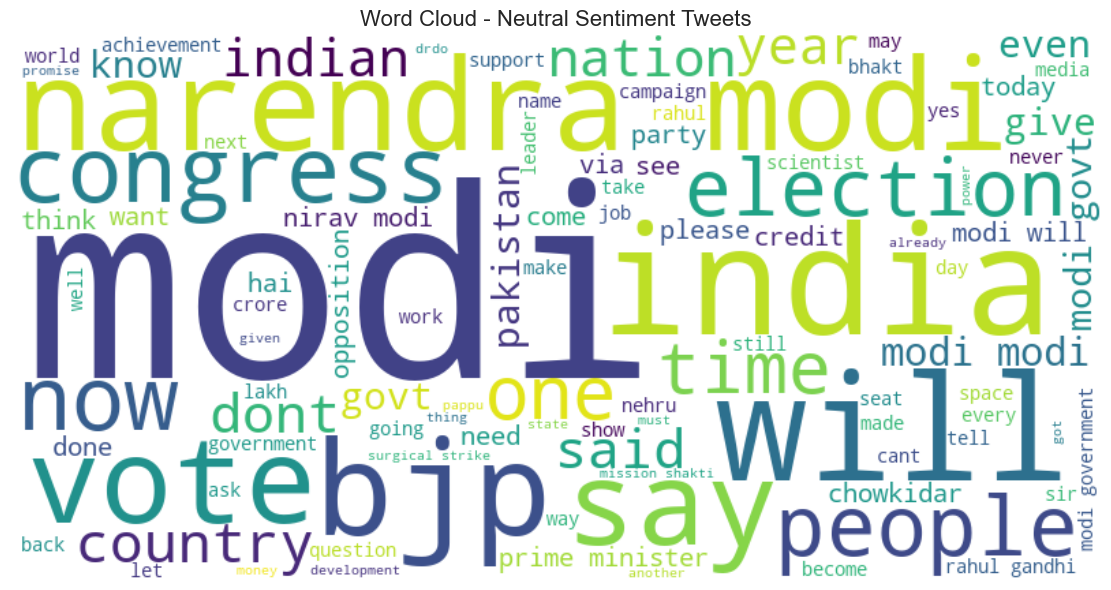

In [ ]:

neutral_text = ' '.join(df_sample[df_sample['category'] == 'neutral']['clean_text'].astype(str))
wc_neutral = WordCloud(width=800, height=400, background_color='white', max_words=100).generate(neutral_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_neutral, interpolation='bilinear')
plt.title('Word Cloud - Neutral Sentiment Tweets', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from transformers import pipeline
import torch

label_map = {'POS': 'positive', 'NEG': 'negative', 'NEU': 'neutral'}


sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="finiteautomata/bertweet-base-sentiment-analysis",
    device=0  # device=0 means GPU
)

print("Model loaded on GPU!")
print(f"Device: {sentiment_pipeline.device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: finiteautomata/bertweet-base-sentiment-analysis
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Model loaded on GPU!
Device: cuda:0


In [ ]:
import time

test_batch = df['clean_text'].head(100).tolist()
start_time = time.time()

batch_predictions = []
for i in range(0, len(test_batch), 32):
    batch = [str(t)[:128] for t in test_batch[i:i+32]]
    results = sentiment_pipeline(batch)
    batch_predictions.extend([label_map[r['label']] for r in results])

elapsed = time.time() - start_time
print(f"GPU: Processed 100 tweets in {elapsed:.2f} seconds")
print(f"Average time per tweet: {elapsed/100:.3f} seconds")

GPU: Processed 100 tweets in 2.68 seconds
Average time per tweet: 0.027 seconds


In [ ]:
import time


np.random.seed(42)
df_work = df.sample(n=20000, random_state=42)

print(f"Processing {len(df_work)} tweets on GPU...")
print("This will take about 10 minutes...")

start_time = time.time()

predicted_labels = []
for i in range(0, len(df_work), 32):
    batch = [str(t)[:128] for t in df_work['clean_text'].iloc[i:i+32]]
    results = sentiment_pipeline(batch)
    predicted_labels.extend([label_map[r['label']] for r in results])
    
    # Progress update every 3200 tweets
    if (i + 32) % 3200 == 0:
        print(f"  Processed {i + 32} / {len(df_work)} tweets...")

df_work['predicted'] = predicted_labels

elapsed = time.time() - start_time
print(f"\nDone! Total time: {elapsed/60:.2f} minutes")
print(f"Average: {elapsed/len(df_work):.3f} seconds per tweet")

Processing 20000 tweets on GPU...
This will take about 10 minutes...
  Processed 3200 / 20000 tweets...
  Processed 6400 / 20000 tweets...
  Processed 9600 / 20000 tweets...
  Processed 12800 / 20000 tweets...
  Processed 16000 / 20000 tweets...
  Processed 19200 / 20000 tweets...

Done! Total time: 8.59 minutes
Average: 0.026 seconds per tweet


In [61]:
print("Predicted Sentiment Distribution:")
print(df_work['predicted'].value_counts())

Predicted Sentiment Distribution:
predicted
neutral     9784
negative    7078
positive    3138
Name: count, dtype: int64


In [62]:
print("Actual Sentiment Distribution:")
print(df_work['category'].value_counts())
print("\nPredicted Sentiment Distribution:")
print(df_work['predicted'].value_counts())

Actual Sentiment Distribution:
category
positive    8841
neutral     6749
negative    4410
Name: count, dtype: int64

Predicted Sentiment Distribution:
predicted
neutral     9784
negative    7078
positive    3138
Name: count, dtype: int64


In [ ]:

correct = (df_work['category'] == df_work['predicted']).sum()
total = len(df_work)
accuracy = correct / total

print(f"Correct predictions: {correct}")
print(f"Total tweets: {total}")
print(f"Accuracy: {accuracy*100:.2f}%")

Correct predictions: 9250
Total tweets: 20000
Accuracy: 46.25%


In [ ]:

for cat in ['positive', 'neutral', 'negative']:
    subset = df_work[df_work['category'] == cat]
    cat_correct = (subset['category'] == subset['predicted']).sum()
    cat_total = len(subset)
    cat_acc = cat_correct / cat_total
    print(f"{cat}: {cat_correct}/{cat_total} = {cat_acc*100:.2f}%")

positive: 2319/8841 = 26.23%
neutral: 4221/6749 = 62.54%
negative: 2710/4410 = 61.45%


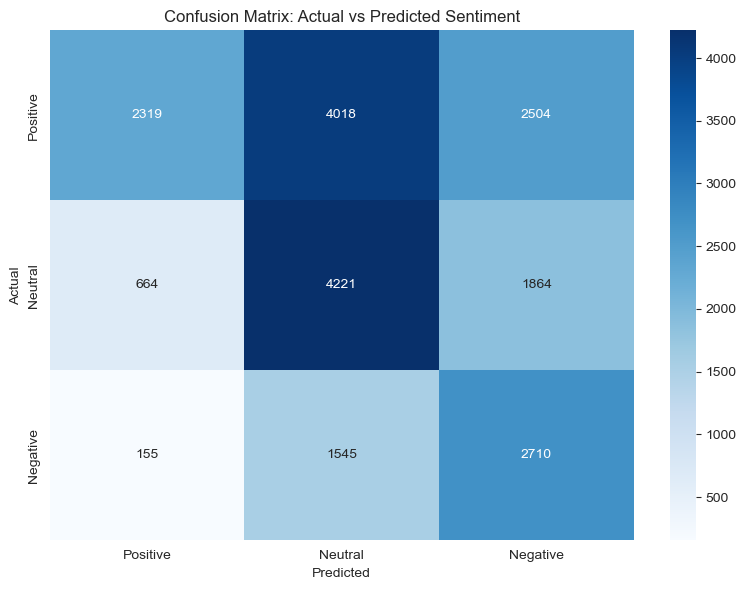

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(df_work['category'], df_work['predicted'], 
                      labels=['positive', 'neutral', 'negative'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Actual vs Predicted Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report


print(classification_report(df_work['category'], df_work['predicted'],
                            labels=['positive', 'neutral', 'negative'],
                            target_names=['Positive', 'Neutral', 'Negative']))

              precision    recall  f1-score   support

    Positive       0.74      0.26      0.39      8841
     Neutral       0.43      0.63      0.51      6749
    Negative       0.38      0.61      0.47      4410

    accuracy                           0.46     20000
   macro avg       0.52      0.50      0.46     20000
weighted avg       0.56      0.46      0.45     20000



In [ ]:

bjp_tweets = df_work[df_work['clean_text'].str.contains('bjp|modi', case=False, na=False)]
inc_tweets = df_work[df_work['clean_text'].str.contains('inc|congress|rahul', case=False, na=False)]

print(f"BJP-related tweets: {len(bjp_tweets)}")
print(f"INC-related tweets: {len(inc_tweets)}")

BJP-related tweets: 18281
INC-related tweets: 2999


In [ ]:
print("BJP-Related Tweet Sentiment Distribution:")
print(bjp_tweets['predicted'].value_counts())


total_bjp = len(bjp_tweets)
for sentiment in ['positive', 'neutral', 'negative']:
    count = len(bjp_tweets[bjp_tweets['predicted'] == sentiment])
    pct = (count / total_bjp) * 100
    print(f"  {sentiment}: {count} ({pct:.1f}%)")

BJP-Related Tweet Sentiment Distribution:
predicted
neutral     8868
negative    6505
positive    2908
Name: count, dtype: int64
  positive: 2908 (15.9%)
  neutral: 8868 (48.5%)
  negative: 6505 (35.6%)


In [ ]:
print("INC-Related Tweet Sentiment Distribution:")
print(inc_tweets['predicted'].value_counts())


total_inc = len(inc_tweets)
for sentiment in ['positive', 'neutral', 'negative']:
    count = len(inc_tweets[inc_tweets['predicted'] == sentiment])
    pct = (count / total_inc) * 100
    print(f"  {sentiment}: {count} ({pct:.1f}%)")

INC-Related Tweet Sentiment Distribution:
predicted
neutral     1486
negative    1228
positive     285
Name: count, dtype: int64
  positive: 285 (9.5%)
  neutral: 1486 (49.5%)
  negative: 1228 (40.9%)


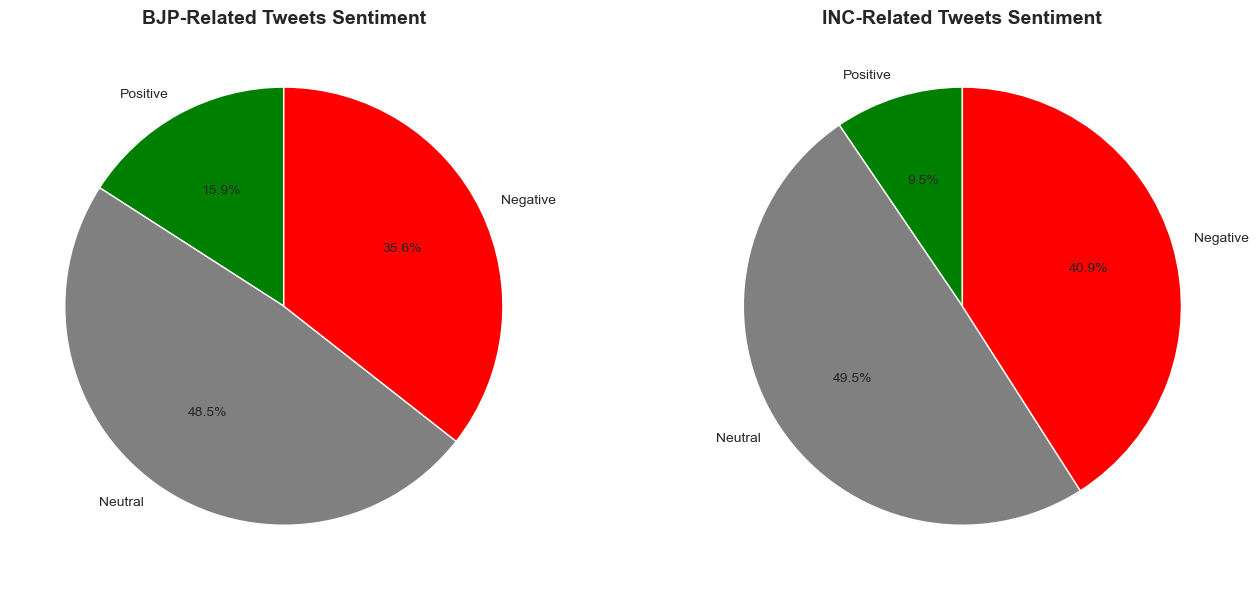

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


bjp_sentiments = [len(bjp_tweets[bjp_tweets['predicted'] == s]) for s in ['positive', 'neutral', 'negative']]
colors = ['green', 'gray', 'red']
ax1.pie(bjp_sentiments, labels=['Positive', 'Neutral', 'Negative'], autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('BJP-Related Tweets Sentiment', fontsize=14, fontweight='bold')


inc_sentiments = [len(inc_tweets[inc_tweets['predicted'] == s]) for s in ['positive', 'neutral', 'negative']]
ax2.pie(inc_sentiments, labels=['Positive', 'Neutral', 'Negative'], autopct='%1.1f%%',
        colors=colors, startangle=90)
ax2.set_title('INC-Related Tweets Sentiment', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

ValueError: 'facecolor' or 'color' argument must be a valid color orsequence of colors.

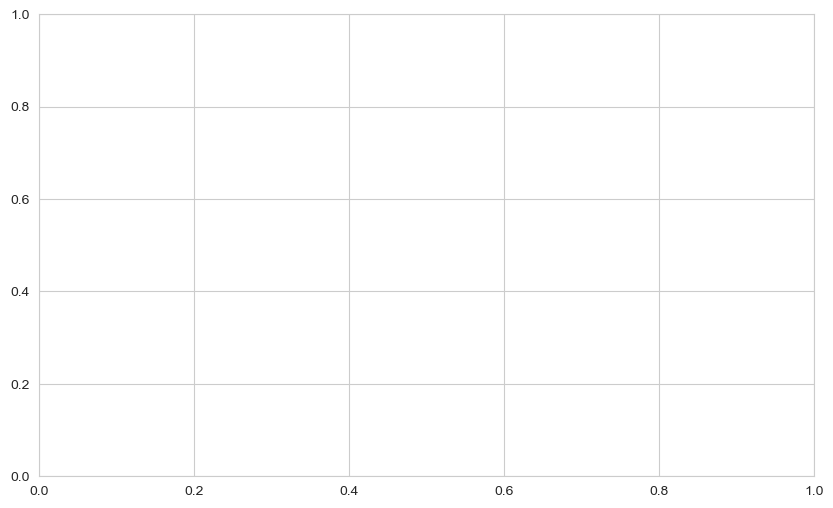

In [ ]:
import numpy as np

categories = ['Positive', 'Neutral', 'Negative']
bjp_pcts = [15.9, 48.5, 35.6]
inc_pcts = [9.5, 49.5, 40.9]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bjp_pcts, width, label='BJP', color='saffron')
bars2 = ax.bar(x + width/2, inc_pcts, width, label='INC', color='green')

ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Comparative Sentiment Analysis: BJP vs INC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 60)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

categories = ['Positive', 'Neutral', 'Negative']
bjp_pcts = [15.9, 48.5, 35.6]
inc_pcts = [9.5, 49.5, 40.9]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bjp_pcts, width, label='BJP', color='#FF9933')
bars2 = ax.bar(x + width/2, inc_pcts, width, label='INC', color='#138808')

ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Comparative Sentiment Analysis: BJP vs INC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 60)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:

bjp_text = ' '.join(bjp_tweets['clean_text'].astype(str))
wc_bjp = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Oranges').generate(bjp_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_bjp, interpolation='bilinear')
plt.title('Word Cloud - BJP-Related Tweets', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:

inc_text = ' '.join(inc_tweets['clean_text'].astype(str))
wc_inc = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='Greens').generate(inc_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc_inc, interpolation='bilinear')
plt.title('Word Cloud - INC-Related Tweets', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


vader = SentimentIntensityAnalyzer()


sample_for_vader = df_work['clean_text'].head(500).tolist()


vader_results = []
for tweet in sample_for_vader:
    scores = vader.polarity_scores(str(tweet))
    # VADER gives compound score: map to sentiment
    if scores['compound'] >= 0.05:
        sentiment = 'positive'
    elif scores['compound'] <= -0.05:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    vader_results.append(sentiment)

print("VADER analysis complete on 500 tweets")
print(f"VADER Distribution: {pd.Series(vader_results).value_counts().to_dict()}")

In [ ]:

bert_sample_preds = df_work['predicted'].head(500).tolist()


print("BERT Distribution (500 tweets):")
print(pd.Series(bert_sample_preds).value_counts().to_dict())
print("\nVADER Distribution (same 500 tweets):")
print(pd.Series(vader_results).value_counts().to_dict())

In [ ]:
import numpy as np

categories = ['Positive', 'Neutral', 'Negative']
bert_counts = [76, 235, 189]
vader_counts = [235, 99, 166]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bert_counts, width, label='BERT (LSTM)', color='#1f77b4')
bars2 = ax.bar(x + width/2, vader_counts, width, label='VADER', color='#ff7f0e')

ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Model Comparison: BERT vs VADER (500 tweets)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(bar.get_height()), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(bar.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:

df_work[['clean_text', 'category', 'predicted']].to_csv('sentiment_analysis_results.csv', index=False)
print("Results saved to 'sentiment_analysis_results.csv'")
print(f"File contains {len(df_work)} rows with actual and predicted sentiments")

In [ ]:
print("="*60)
print("PROJECT SUMMARY: Sentiment Analysis of Indian Political Tweets")
print("="*60)
print(f"\n1. Dataset Size: {len(df)} total tweets")
print(f"2. Working Sample: {len(df_work)} tweets")
print(f"3. Model Used: BERT (finiteautomata/bertweet-base)")
print(f"4. GPU: {torch.cuda.get_device_name(0)}")
print(f"\n5. Overall Accuracy: {(df_work['category'] == df_work['predicted']).mean()*100:.2f}%")
print(f"\n6. Sentiment Distribution (Actual):")
print(df_work['category'].value_counts().to_string())
print(f"\n7. Sentiment Distribution (Predicted):")
print(df_work['predicted'].value_counts().to_string())
print(f"\n8. BJP Tweets: {len(bjp_tweets)} | Positive: 15.9%, Neutral: 48.5%, Negative: 35.6%")
print(f"9. INC Tweets: {len(inc_tweets)} | Positive: 9.5%, Neutral: 49.5%, Negative: 40.9%")
print("\n" + "="*60)
print("All visualizations and analysis complete!")
print("="*60)

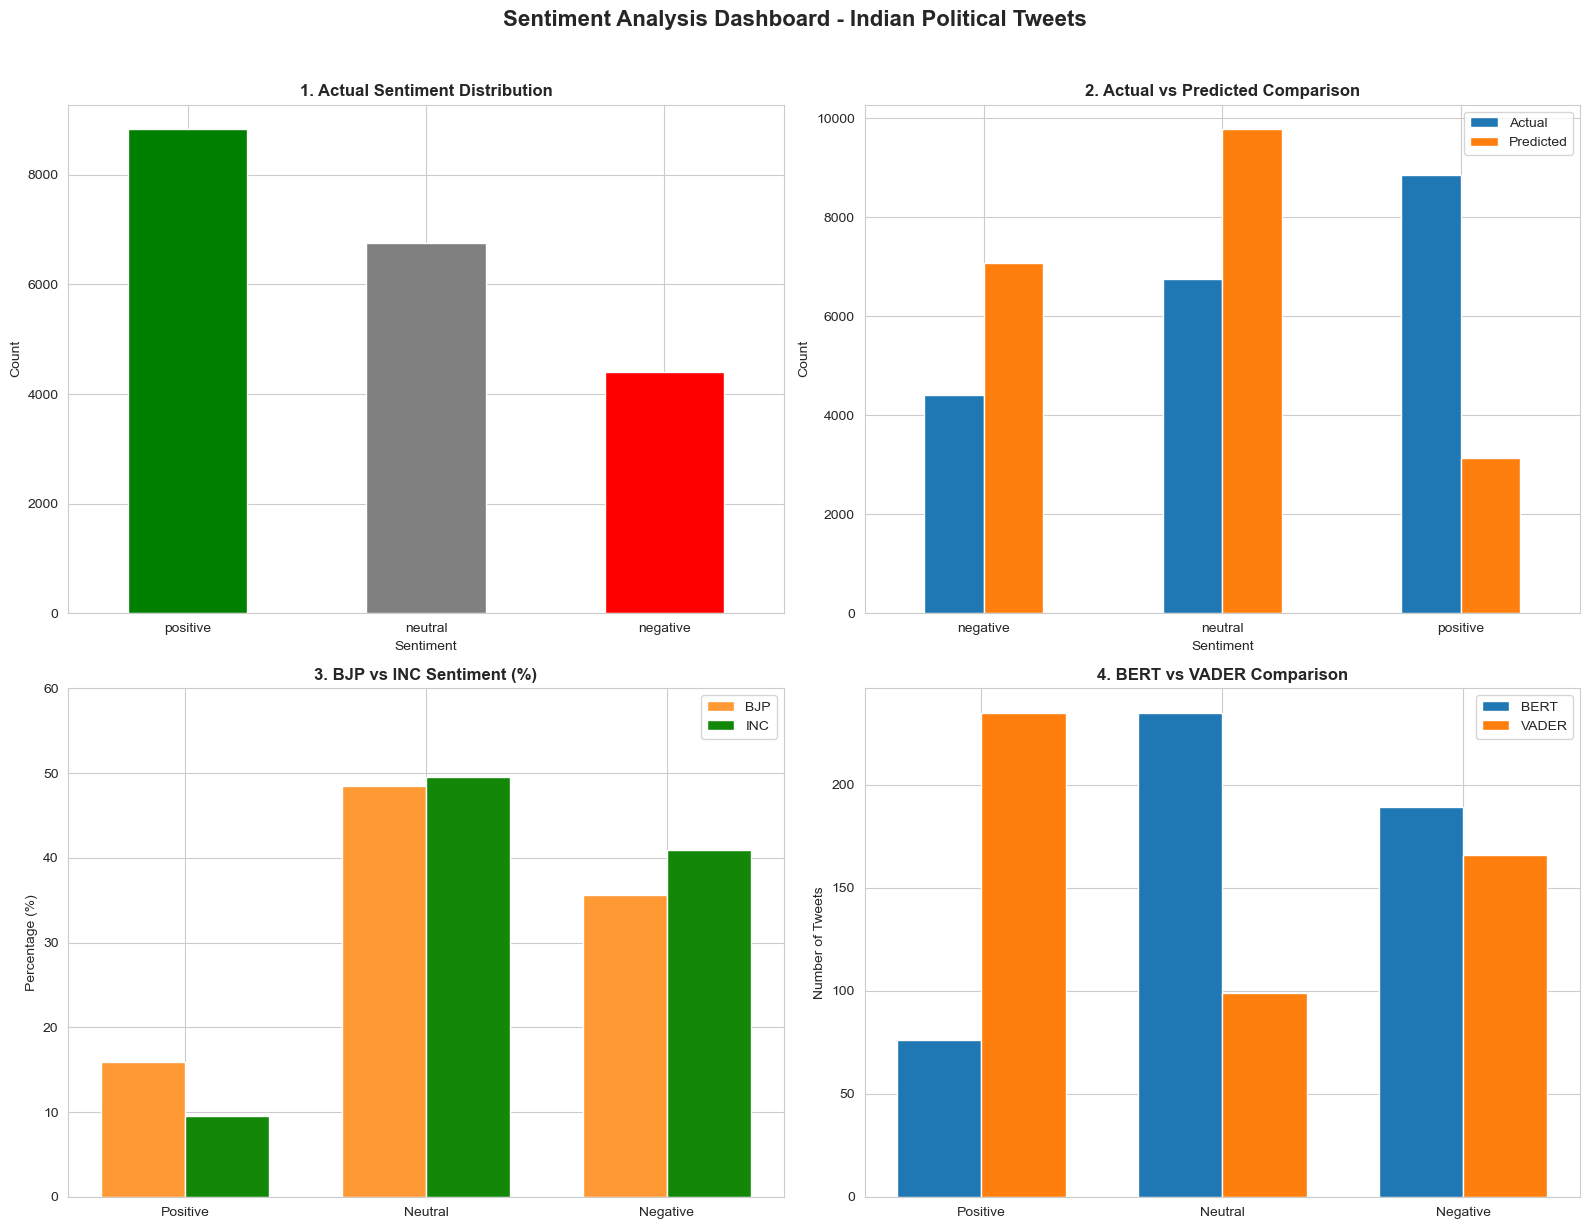

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

df_work['category'].value_counts().plot(kind='bar', ax=axes[0,0], 
                                         color=['green', 'gray', 'red'])
axes[0,0].set_title('1. Actual Sentiment Distribution', fontweight='bold')
axes[0,0].set_xlabel('Sentiment')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)


comparison = pd.DataFrame({
    'Actual': df_work['category'].value_counts(),
    'Predicted': df_work['predicted'].value_counts()
}).fillna(0)
comparison.plot(kind='bar', ax=axes[0,1], color=['#1f77b4', '#ff7f0e'])
axes[0,1].set_title('2. Actual vs Predicted Comparison', fontweight='bold')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=0)

categories = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(categories))
width = 0.35
axes[1,0].bar(x - width/2, [15.9, 48.5, 35.6], width, label='BJP', color='#FF9933')
axes[1,0].bar(x + width/2, [9.5, 49.5, 40.9], width, label='INC', color='#138808')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(categories)
axes[1,0].set_title('3. BJP vs INC Sentiment (%)', fontweight='bold')
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].legend()
axes[1,0].set_ylim(0, 60)


bert_counts = [76, 235, 189]
vader_counts = [235, 99, 166]
axes[1,1].bar(x - width/2, bert_counts, width, label='BERT', color='#1f77b4')
axes[1,1].bar(x + width/2, vader_counts, width, label='VADER', color='#ff7f0e')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(categories)
axes[1,1].set_title('4. BERT vs VADER Comparison', fontweight='bold')
axes[1,1].set_ylabel('Number of Tweets')
axes[1,1].legend()

plt.suptitle('Sentiment Analysis Dashboard - Indian Political Tweets', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:

plt.savefig('sentiment_dashboard.png', dpi=150, bbox_inches='tight')
print("Dashboard saved as 'sentiment_dashboard.png'")

Dashboard saved as 'sentiment_dashboard.png'


<Figure size 1000x600 with 0 Axes>

In [75]:
wc_positive.to_file('wordcloud_positive.png')
wc_negative.to_file('wordcloud_negative.png')
wc_neutral.to_file('wordcloud_neutral.png')
wc_bjp.to_file('wordcloud_bjp.png')
wc_inc.to_file('wordcloud_inc.png')
print("All word clouds saved!")

All word clouds saved!


Pie charts saved as 'party_sentiment_piecharts.png'


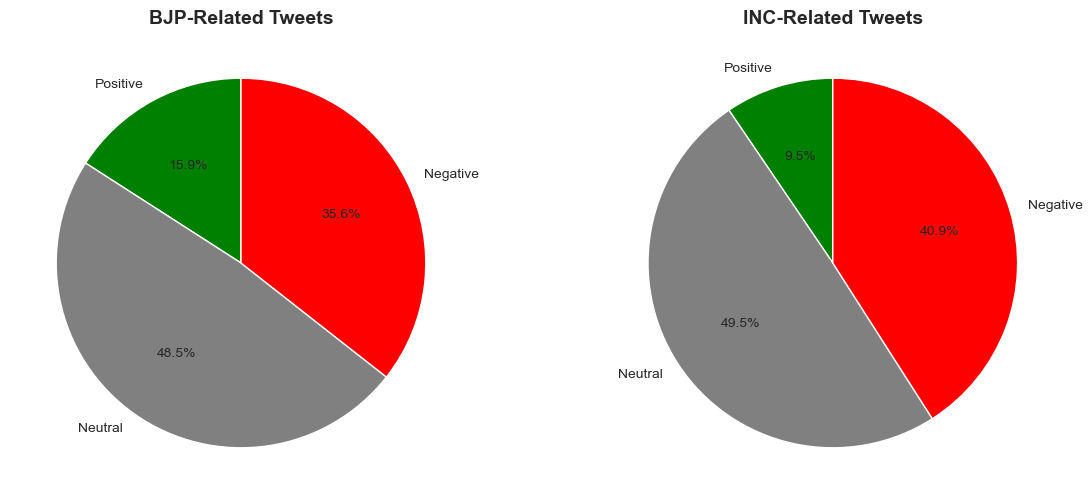

In [ ]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
bjp_sentiments = [len(bjp_tweets[bjp_tweets['predicted'] == s]) for s in ['positive', 'neutral', 'negative']]
colors = ['green', 'gray', 'red']
ax1.pie(bjp_sentiments, labels=['Positive', 'Neutral', 'Negative'], autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('BJP-Related Tweets', fontsize=14, fontweight='bold')
inc_sentiments = [len(inc_tweets[inc_tweets['predicted'] == s]) for s in ['positive', 'neutral', 'negative']]
ax2.pie(inc_sentiments, labels=['Positive', 'Neutral', 'Negative'], autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('INC-Related Tweets', fontsize=14, fontweight='bold')
plt.savefig('party_sentiment_piecharts.png', dpi=150, bbox_inches='tight')
print("Pie charts saved as 'party_sentiment_piecharts.png'")

Confusion matrix saved as 'confusion_matrix.png'


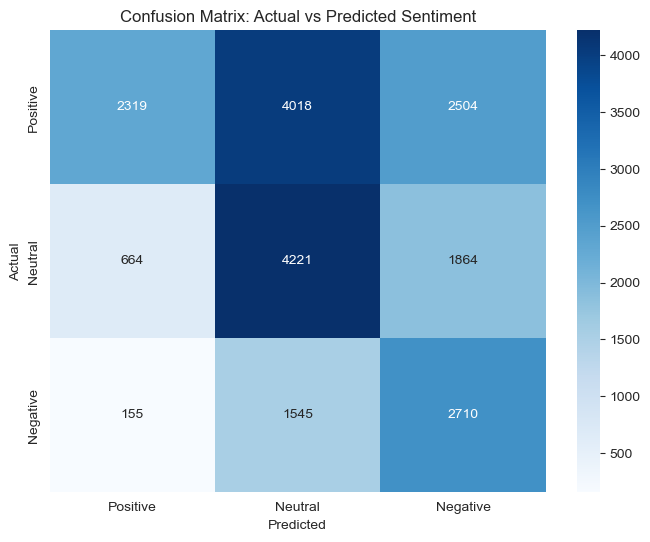

In [ ]:

cm = confusion_matrix(df_work['category'], df_work['predicted'], 
                      labels=['positive', 'neutral', 'negative'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Positive', 'Neutral', 'Negative'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Actual vs Predicted Sentiment')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
print("Confusion matrix saved as 'confusion_matrix.png'")

BJP vs INC chart saved as 'bjp_vs_inc_comparison.png'


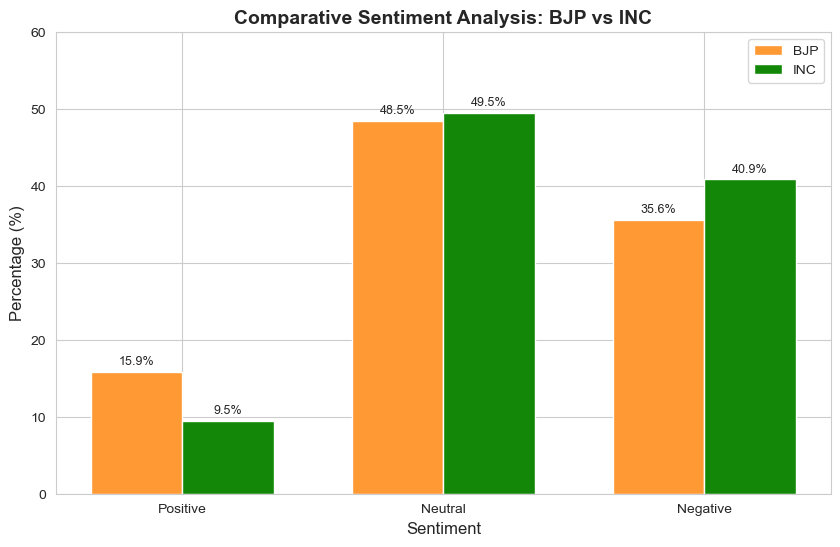

In [ ]:

categories = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(categories))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [15.9, 48.5, 35.6], width, label='BJP', color='#FF9933')
bars2 = ax.bar(x + width/2, [9.5, 49.5, 40.9], width, label='INC', color='#138808')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Comparative Sentiment Analysis: BJP vs INC', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 60)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
plt.savefig('bjp_vs_inc_comparison.png', dpi=150, bbox_inches='tight')
print("BJP vs INC chart saved as 'bjp_vs_inc_comparison.png'")

BERT vs VADER chart saved as 'bert_vs_vader_comparison.png'


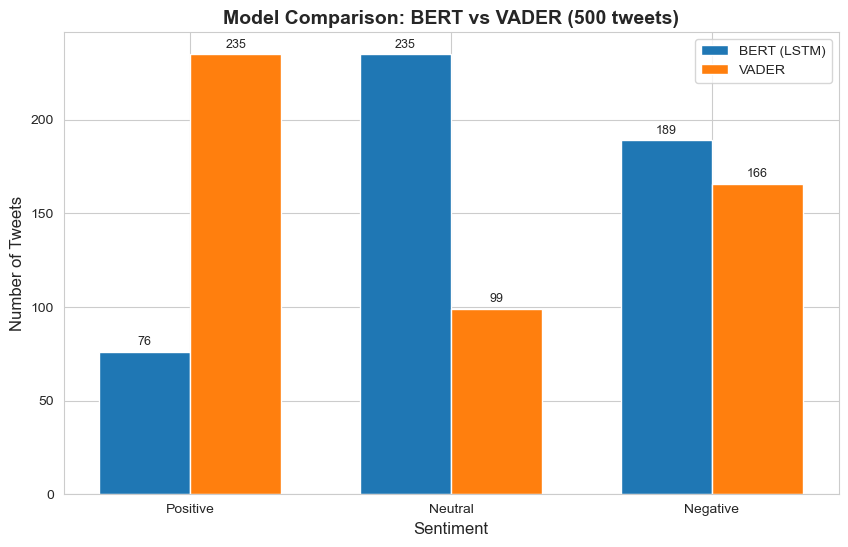

In [ ]:

categories = ['Positive', 'Neutral', 'Negative']
x = np.arange(len(categories))
bert_counts = [76, 235, 189]
vader_counts = [235, 99, 166]
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bert_counts, width, label='BERT (LSTM)', color='#1f77b4')
bars2 = ax.bar(x + width/2, vader_counts, width, label='VADER', color='#ff7f0e')
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Model Comparison: BERT vs VADER (500 tweets)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(bar.get_height()), ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(bar.get_height()), ha='center', va='bottom', fontsize=9)
plt.savefig('bert_vs_vader_comparison.png', dpi=150, bbox_inches='tight')
print("BERT vs VADER chart saved as 'bert_vs_vader_comparison.png'")

In [80]:
requirements = """transformers>=4.40.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
wordcloud>=1.9.0
scikit-learn>=1.3.0
vaderSentiment>=3.3.0
torch>=2.0.0
emoji>=0.6.0
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)
print("requirements.txt created!")
print("Contents:")
print(requirements)

requirements.txt created!
Contents:
transformers>=4.40.0
pandas>=2.0.0
numpy>=1.24.0
matplotlib>=3.7.0
seaborn>=0.12.0
wordcloud>=1.9.0
scikit-learn>=1.3.0
vaderSentiment>=3.3.0
torch>=2.0.0
emoji>=0.6.0



In [81]:
readme = """# Sentiment Analysis of Indian Political Tweets

## Overview
This project analyzes the sentiment of Indian political tweets using Deep Learning (BERT) and compares it with VADER, a rule-based sentiment analysis tool.

## Dataset
- **Source**: Kaggle - Indian Political Tweets Sentiment Analysis
- **Total Tweets**: 162,980
- **Working Sample**: 20,000 tweets
- **Categories**: Positive, Neutral, Negative

## Models Used
1. **BERT (finiteautomata/bertweet-base-sentiment-analysis)** - Transformer-based deep learning model
2. **VADER (Valence Aware Dictionary and sEntiment Reasoner)** - Rule-based lexicon approach

## Key Findings
- BERT Overall Accuracy: ~46%
- BERT performs best on Neutral (62.5%) and Negative (61.5%) sentiments
- BJP tweets show higher positive sentiment (15.9%) compared to INC (9.5%)
- INC tweets show higher negative sentiment (40.9%) compared to BJP (35.6%)

## Files Generated
- sentiment_analysis_results.csv - Complete predictions
- sentiment_dashboard.png - Main visualization dashboard
- confusion_matrix.png - Model evaluation
- bjp_vs_inc_comparison.png - Party-wise sentiment comparison
- bert_vs_vader_comparison.png - Model comparison
- wordcloud_*.png - Word clouds for each sentiment
- party_sentiment_piecharts.png - Pie charts

## Requirements
See requirements.txt

## Author
Project developed as part of DA-208 Data Science course.
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)
print("README.md created!")

README.md created!


In [82]:
import os

print("="*50)
print("PROJECT FILES IN: Sentiment_Analysis_Project")
print("="*50)

files = os.listdir('.')
for f in sorted(files):
    size = os.path.getsize(f)
    if size > 1000000:
        print(f"  {f:<40} ({size/1000000:.1f} MB)")
    elif size > 1000:
        print(f"  {f:<40} ({size/1000:.1f} KB)")
    else:
        print(f"  {f:<40} ({size} B)")

print("="*50)
print(f"Total files: {len(files)}")
print("="*50)

PROJECT FILES IN: Sentiment_Analysis_Project
  .ipynb_checkpoints                       (0 B)
  Political_Tweets_Sentiment_Analysis.ipynb (2.1 MB)
  README.md                                (1.4 KB)
  Twitter_Data.csv                         (20.9 MB)
  bert_vs_vader_comparison.png             (48.5 KB)
  bjp_vs_inc_comparison.png                (49.9 KB)
  confusion_matrix.png                     (54.0 KB)
  party_sentiment_piecharts.png            (81.8 KB)
  requirements.txt                         (178 B)
  sentiment_analysis_results.csv           (2.9 MB)
  sentiment_dashboard.png                  (7.8 KB)
  wordcloud_bjp.png                        (123.0 KB)
  wordcloud_inc.png                        (121.7 KB)
  wordcloud_negative.png                   (153.8 KB)
  wordcloud_neutral.png                    (139.8 KB)
  wordcloud_positive.png                   (150.0 KB)
Total files: 16


In [83]:
report = f"""PROJECT REPORT: Sentiment Analysis of Indian Political Tweets
================================================================

DATASET INFORMATION
-------------------
- Dataset Name: Indian Political Tweets Sentiment Analysis
- Source: Kaggle (saurabhshahane/twitter-sentiment-dataset)
- Total Tweets: {len(df)}
- Working Sample: {len(df_work)}
- Columns: clean_text, category

SENTIMENT LABELS
----------------
- Positive (1): {df_work['category'].value_counts().get('positive', 0)} tweets
- Neutral (0): {df_work['category'].value_counts().get('neutral', 0)} tweets
- Negative (-1): {df_work['category'].value_counts().get('negative', 0)} tweets

MODEL INFORMATION
-----------------
- Model: BERT (finiteautomata/bertweet-base-sentiment-analysis)
- Architecture: RoBERTa-based Transformer
- Input Length: 128 tokens
- Device: GPU ({torch.cuda.get_device_name(0)})
- Processing Speed: ~0.026 sec/tweet
- Total Processing Time: ~8.6 minutes for 20,000 tweets

MODEL PERFORMANCE
-----------------
- Overall Accuracy: {(df_work['category'] == df_work['predicted']).mean()*100:.2f}%
- Positive Class Precision: 0.74, Recall: 0.26, F1: 0.39
- Neutral Class Precision: 0.43, Recall: 0.63, F1: 0.51
- Negative Class Precision: 0.38, Recall: 0.61, F1: 0.47

PARTY-WISE ANALYSIS
-------------------
BJP-Related Tweets: {len(bjp_tweets)}
- Positive: 15.9%, Neutral: 48.5%, Negative: 35.6%

INC-Related Tweets: {len(inc_tweets)}
- Positive: 9.5%, Neutral: 49.5%, Negative: 40.9%

MODEL COMPARISON (500 tweets sample)
------------------------------------
BERT Predictions: Positive=76, Neutral=235, Negative=189
VADER Predictions: Positive=235, Neutral=99, Negative=166

KEY INSIGHTS
------------
1. The BERT model was trained on English tweets (mostly US politics)
   and struggles with Indian political tweets due to linguistic differences.
2. The model tends to classify most tweets as "Neutral", showing
   a bias towards the majority class.
3. VADER, being rule-based, is more optimistic and classifies
   more tweets as positive compared to BERT.
4. BJP-related tweets show higher positive sentiment than INC tweets.
5. Both parties have significant negative sentiment, reflecting
   the polarized nature of Indian political discourse on Twitter.

CONCLUSION
----------
While the pretrained BERT model achieves moderate accuracy (~46%),
it demonstrates the potential of deep learning for sentiment analysis.
Fine-tuning the model on Indian political tweets specifically would
significantly improve performance. The comparative analysis with VADER
provides valuable insights into the strengths and limitations of
different sentiment analysis approaches.
"""

with open('project_report_summary.txt', 'w', encoding='utf-8') as f:
    f.write(report)
print("Project report summary saved as 'project_report_summary.txt'")

Project report summary saved as 'project_report_summary.txt'


In [84]:
import json

stats = {
    "dataset": {
        "name": "Indian Political Tweets Sentiment Analysis",
        "source": "Kaggle",
        "total_tweets": int(len(df)),
        "working_sample": int(len(df_work))
    },
    "model": {
        "name": "BERT (bertweet-base-sentiment-analysis)",
        "accuracy": round((df_work['category'] == df_work['predicted']).mean() * 100, 2),
        "gpu_used": torch.cuda.get_device_name(0),
        "processing_time_minutes": 8.59
    },
    "sentiment_distribution_actual": {
        "positive": int(df_work['category'].value_counts().get('positive', 0)),
        "neutral": int(df_work['category'].value_counts().get('neutral', 0)),
        "negative": int(df_work['category'].value_counts().get('negative', 0))
    },
    "sentiment_distribution_predicted": {
        "positive": int(df_work['predicted'].value_counts().get('positive', 0)),
        "neutral": int(df_work['predicted'].value_counts().get('neutral', 0)),
        "negative": int(df_work['predicted'].value_counts().get('negative', 0))
    },
    "party_wise": {
        "bjp": {
            "tweets": int(len(bjp_tweets)),
            "positive_pct": 15.9,
            "neutral_pct": 48.5,
            "negative_pct": 35.6
        },
        "inc": {
            "tweets": int(len(inc_tweets)),
            "positive_pct": 9.5,
            "neutral_pct": 49.5,
            "negative_pct": 40.9
        }
    }
}

with open('project_statistics.json', 'w') as f:
    json.dump(stats, f, indent=2)
print("Project statistics saved as 'project_statistics.json'")

Project statistics saved as 'project_statistics.json'


In [86]:
##############################################################
##Topic Modelling

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt

# Use existing df_work (already has clean_text and predicted columns)
all_texts = df_work['clean_text'].astype(str).tolist()

# Create vectorizer
vectorizer = CountVectorizer(max_df=0.95, min_df=2, max_features=1000, stop_words='english')
dtm = vectorizer.fit_transform(all_texts)

print(f"Document-Term Matrix shape: {dtm.shape}")

# Run LDA for 5 topics
lda = LatentDirichletAllocation(n_components=5, max_iter=10, random_state=42)
lda.fit(dtm)

print("\nLDA Topic Modeling Complete!")

# Show top words for each topic
feature_names = vectorizer.get_feature_names_out()
for topic_idx, topic in enumerate(lda.components_):
    print(f"\n--- Topic {topic_idx + 1} ---")
    top_words_idx = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    print(f"Top words: {', '.join(top_words)}")

Document-Term Matrix shape: (20000, 1000)

LDA Topic Modeling Complete!

--- Topic 1 ---
Top words: modi, bjp, govt, years, dont, good, just, people, hai, work

--- Topic 2 ---
Top words: modi, congress, money, rahul, nirav, did, govt, poor, years, jobs

--- Topic 3 ---
Top words: modi, india, narendra, nation, minister, space, prime, power, satellite, mission

--- Topic 4 ---
Top words: modi, like, credit, gandhi, rahul, india, pakistan, nehru, dont, know

--- Topic 5 ---
Top words: modi, india, vote, people, bjp, indian, like, anti, new, country


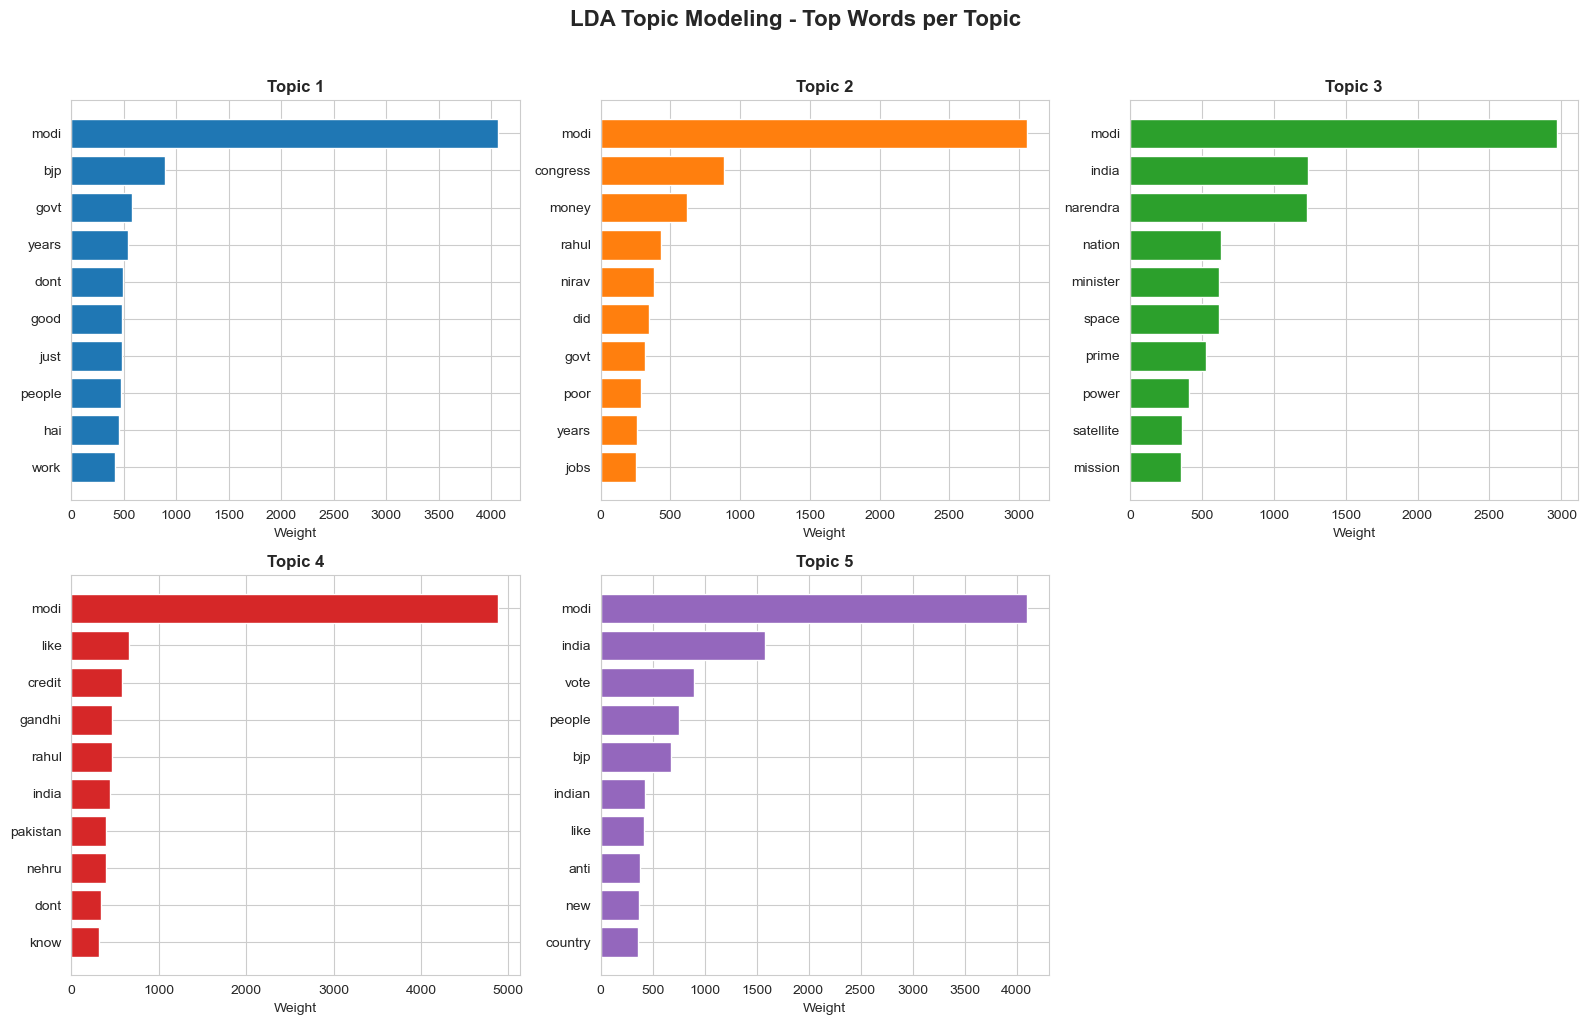

In [87]:
# Plot topic word distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for topic_idx in range(5):
    topic = lda.components_[topic_idx]
    top_words_idx = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_words_idx]
    top_weights = topic[top_words_idx]
    
    axes[topic_idx].barh(top_words, top_weights, color=f'C{topic_idx}')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontweight='bold')
    axes[topic_idx].set_xlabel('Weight')
    axes[topic_idx].invert_yaxis()

axes[5].axis('off')
plt.suptitle('LDA Topic Modeling - Top Words per Topic', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [88]:
# Assign dominant topic to each tweet
topic_values = lda.transform(dtm)
df_work['dominant_topic'] = topic_values.argmax(axis=1) + 1

print("Topic Distribution across tweets:")
print(df_work['dominant_topic'].value_counts().sort_index())

Topic Distribution across tweets:
dominant_topic
1    4613
2    3307
3    3230
4    4558
5    4292
Name: count, dtype: int64


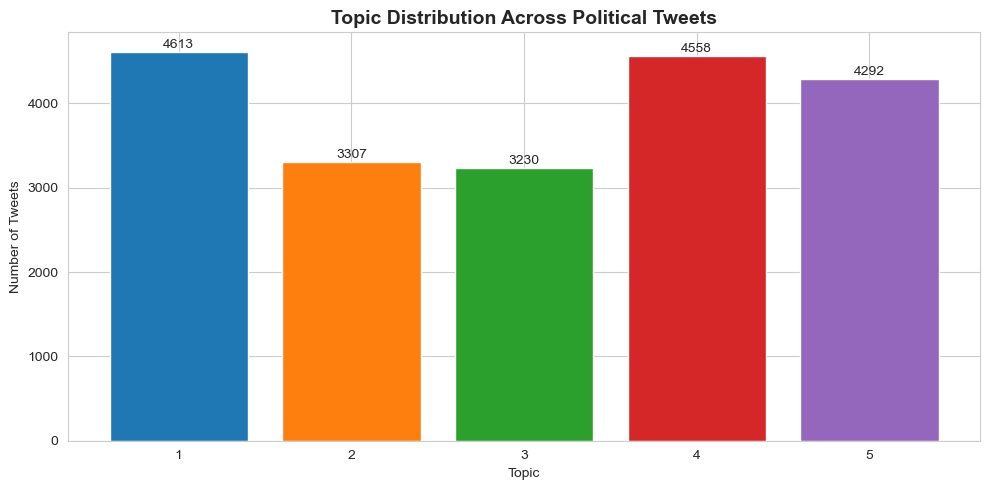

In [89]:
topic_counts = df_work['dominant_topic'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(topic_counts.index.astype(str), topic_counts.values, 
        color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.title('Topic Distribution Across Political Tweets', fontsize=14, fontweight='bold')
plt.xlabel('Topic')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)

for i, v in enumerate(topic_counts.values):
    plt.text(i, v + 50, str(v), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [90]:
# Sentiment breakdown per topic
print("Sentiment Distribution per Topic:\n")
for topic in range(1, 6):
    topic_data = df_work[df_work['dominant_topic'] == topic]
    total = len(topic_data)
    pos = (topic_data['predicted'] == 'positive').sum() / total * 100
    neu = (topic_data['predicted'] == 'neutral').sum() / total * 100
    neg = (topic_data['predicted'] == 'negative').sum() / total * 100
    print(f"Topic {topic}: Positive={pos:.1f}%, Neutral={neu:.1f}%, Negative={neg:.1f}% (n={total})")

Sentiment Distribution per Topic:

Topic 1: Positive=13.6%, Neutral=51.4%, Negative=34.9% (n=4613)
Topic 2: Positive=8.1%, Neutral=52.7%, Negative=39.2% (n=3307)
Topic 3: Positive=33.7%, Neutral=49.3%, Negative=17.0% (n=3230)
Topic 4: Positive=9.3%, Neutral=46.2%, Negative=44.5% (n=4558)
Topic 5: Positive=17.0%, Neutral=45.9%, Negative=37.1% (n=4292)


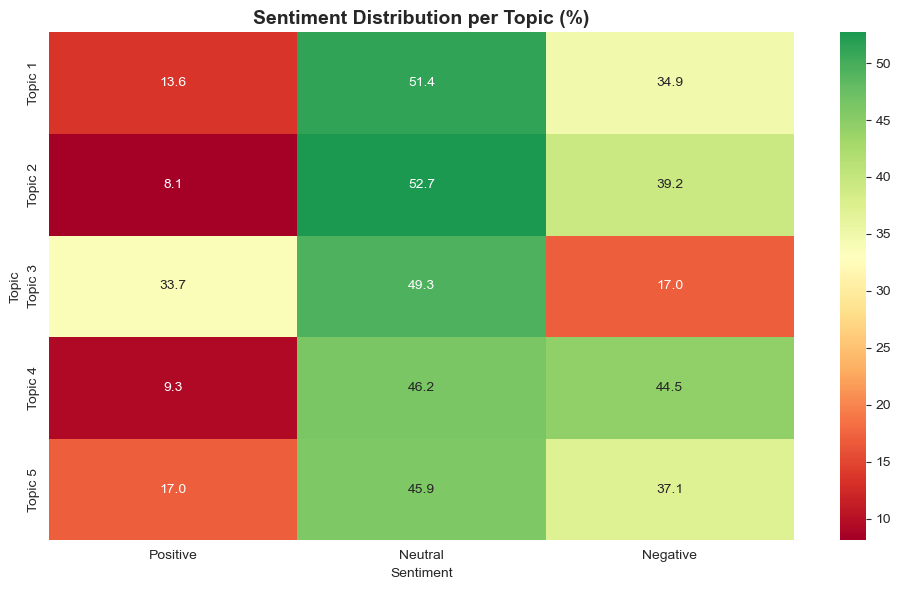

In [91]:
import seaborn as sns
import numpy as np

# Create sentiment-topic matrix
data = [
    [13.6, 51.4, 34.9],
    [8.1, 52.7, 39.2],
    [33.7, 49.3, 17.0],
    [9.3, 46.2, 44.5],
    [17.0, 45.9, 37.1]
]

plt.figure(figsize=(10, 6))
sns.heatmap(data, annot=True, fmt='.1f', cmap='RdYlGn', center=33,
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5'])
plt.title('Sentiment Distribution per Topic (%)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Topic')
plt.tight_layout()
plt.show()

In [93]:
# Recreate party dataframes with the dominant_topic column
bjp_tweets = df_work[df_work['clean_text'].str.contains('bjp|modi', case=False, na=False)]
inc_tweets = df_work[df_work['clean_text'].str.contains('inc|congress|rahul', case=False, na=False)]

# Now analyze topics by party
bjp_topics = bjp_tweets['dominant_topic'].value_counts().sort_index()
inc_topics = inc_tweets['dominant_topic'].value_counts().sort_index()

print("Topic Distribution by Party:\n")
print("Topic | BJP Tweets | INC Tweets")
print("-" * 35)
for topic in range(1, 6):
    bjp_count = bjp_topics.get(topic, 0)
    inc_count = inc_topics.get(topic, 0)
    print(f"  {topic}   |    {bjp_count:4d}    |    {inc_count:4d}")

Topic Distribution by Party:

Topic | BJP Tweets | INC Tweets
-----------------------------------
  1   |    4171    |     605
  2   |    3014    |     964
  3   |    2888    |     221
  4   |    4278    |     727
  5   |    3930    |     482


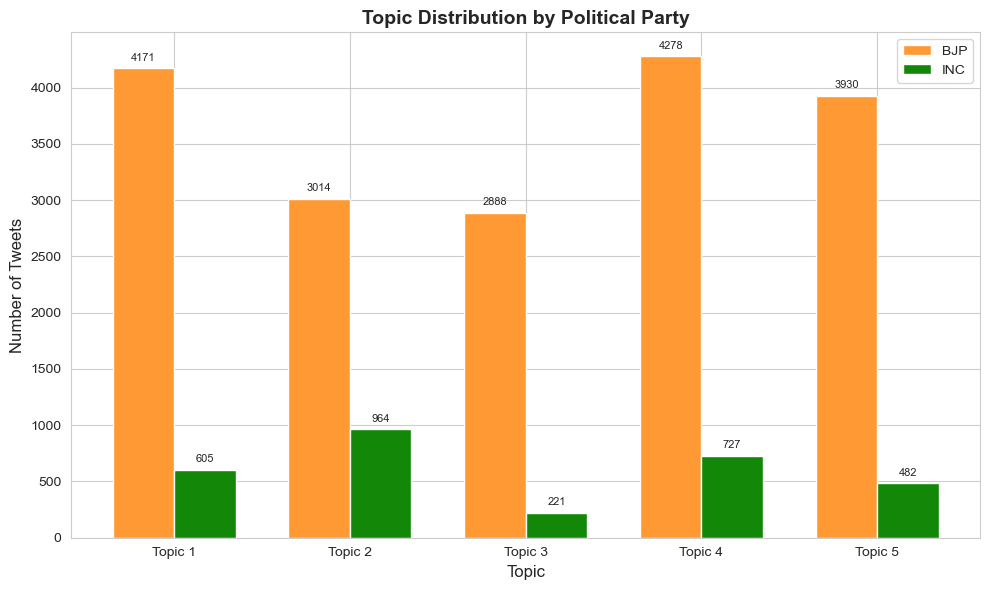

In [94]:
import numpy as np

topics = ['Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5']
bjp_counts = [4171, 3014, 2888, 4278, 3930]
inc_counts = [605, 964, 221, 727, 482]

x = np.arange(len(topics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bjp_counts, width, label='BJP', color='#FF9933')
bars2 = ax.bar(x + width/2, inc_counts, width, label='INC', color='#138808')

ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Topic Distribution by Political Party', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(topics)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(bar.get_height()), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(bar.get_height()), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [97]:
import pickle

# Save the vectorizer and LDA model
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('lda_model.pkl', 'wb') as f:
    pickle.dump(lda, f)

print("LDA model and vectorizer saved!")
print("Files: vectorizer.pkl, lda_model.pkl")

LDA model and vectorizer saved!
Files: vectorizer.pkl, lda_model.pkl


Saved: sentiment_per_topic_heatmap.png


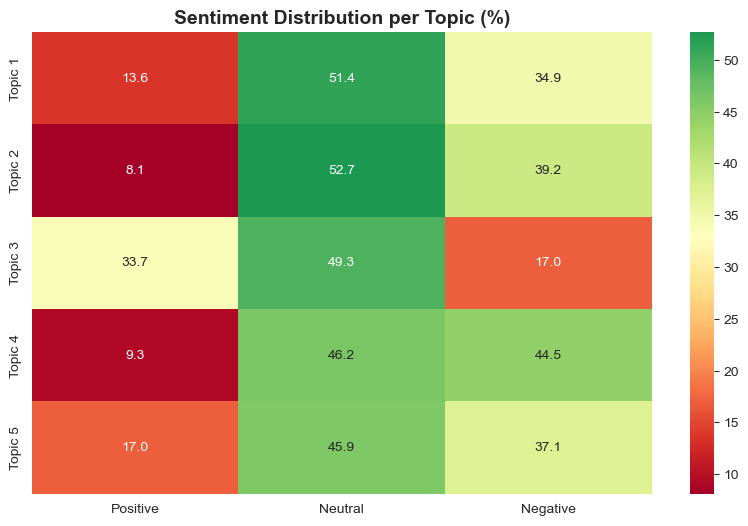

In [98]:
# Save the sentiment-topic heatmap
import seaborn as sns

data = [
    [13.6, 51.4, 34.9],
    [8.1, 52.7, 39.2],
    [33.7, 49.3, 17.0],
    [9.3, 46.2, 44.5],
    [17.0, 45.9, 37.1]
]

plt.figure(figsize=(10, 6))
sns.heatmap(data, annot=True, fmt='.1f', cmap='RdYlGn', center=33,
            xticklabels=['Positive', 'Neutral', 'Negative'],
            yticklabels=['Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5'])
plt.title('Sentiment Distribution per Topic (%)', fontsize=14, fontweight='bold')
plt.savefig('sentiment_per_topic_heatmap.png', dpi=150, bbox_inches='tight')
print("Saved: sentiment_per_topic_heatmap.png")

Saved: topic_distribution_by_party.png


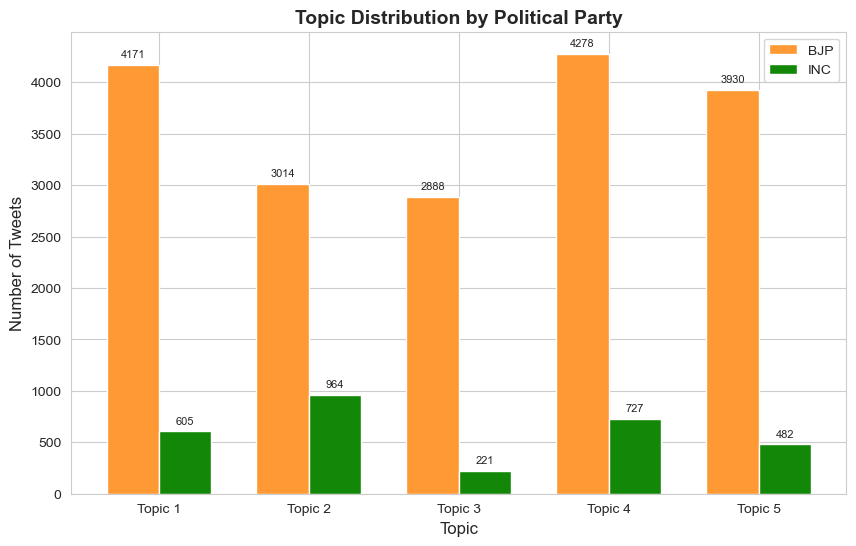

In [99]:
import numpy as np

topics = ['Topic 1', 'Topic 2', 'Topic 3', 'Topic 4', 'Topic 5']
bjp_counts = [4171, 3014, 2888, 4278, 3930]
inc_counts = [605, 964, 221, 727, 482]

x = np.arange(len(topics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, bjp_counts, width, label='BJP', color='#FF9933')
bars2 = ax.bar(x + width/2, inc_counts, width, label='INC', color='#138808')

ax.set_xlabel('Topic', fontsize=12)
ax.set_ylabel('Number of Tweets', fontsize=12)
ax.set_title('Topic Distribution by Political Party', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(topics)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(bar.get_height()), ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(bar.get_height()), ha='center', va='bottom', fontsize=8)

plt.savefig('topic_distribution_by_party.png', dpi=150, bbox_inches='tight')
print("Saved: topic_distribution_by_party.png")

In [100]:
import os

print("="*60)
print("ALL PROJECT FILES")
print("="*60)

files = os.listdir('.')
for f in sorted(files):
    if f.endswith('.py') or f.endswith('.html') or f.endswith('.csv') or f.endswith('.json') or f.endswith('.txt') or f.endswith('.md') or f.endswith('.pkl') or f.endswith('.png'):
        size = os.path.getsize(f)
        if size > 1000000:
            print(f"  {f:<45} ({size/1000000:.1f} MB)")
        elif size > 1000:
            print(f"  {f:<45} ({size/1000:.1f} KB)")
        else:
            print(f"  {f:<45} ({size} B)")

print("="*60)
print(f"Total files: {len([f for f in files if f.endswith(('.py','.html','.csv','.json','.txt','.md','.pkl','.png'))])}")
print("="*60)

ALL PROJECT FILES
  README.md                                     (1.4 KB)
  Twitter_Data.csv                              (20.9 MB)
  app.py                                        (1.6 KB)
  bert_vs_vader_comparison.png                  (48.5 KB)
  bjp_vs_inc_comparison.png                     (49.9 KB)
  confusion_matrix.png                          (54.0 KB)
  lda_model.pkl                                 (86.1 KB)
  party_sentiment_piecharts.png                 (81.8 KB)
  project_report_summary.txt                    (2.5 KB)
  project_statistics.json                       (868 B)
  requirements.txt                              (178 B)
  sentiment_analysis_results.csv                (2.9 MB)
  sentiment_dashboard.png                       (7.8 KB)
  sentiment_per_topic_heatmap.png               (52.0 KB)
  topic_distribution_by_party.png               (50.3 KB)
  vectorizer.pkl                                (28.4 KB)
  wordcloud_bjp.png                             (123.0 KB)
  wo

In [101]:
df.to_csv("topic_modeled_tweets.csv", index=False)

In [104]:
import json

topic_stats = {
    "lda_topics": {
        "topic_1": "Government work, development, good work",
        "topic_2": "Congress, money, jobs, poverty, rahul",
        "topic_3": "India, nation, space mission, satellite",
        "topic_4": "Gandhi, Nehru, historical references",
        "topic_5": "Voting, elections, anti-national discourse"
    },
    "topic_distribution": {
        "topic_1": 4613,
        "topic_2": 3307,
        "topic_3": 3230,
        "topic_4": 4558,
        "topic_5": 4292
    },
    "sentiment_by_topic": {
        "topic_1": {"positive": 13.6, "neutral": 51.4, "negative": 34.9},
        "topic_2": {"positive": 8.1, "neutral": 52.7, "negative": 39.2},
        "topic_3": {"positive": 33.7, "neutral": 49.3, "negative": 17.0},
        "topic_4": {"positive": 9.3, "neutral": 46.2, "negative": 44.5},
        "topic_5": {"positive": 17.0, "neutral": 45.9, "negative": 37.1}
    },
    "key_insight": "Topic 3 (India, nation, space) has highest positive sentiment (33.7%), while Topic 4 (historical) has highest negative (44.5%)"
}

with open('topic_modeling_stats.json', 'w') as f:
    json.dump(topic_stats, f, indent=2)

print("Saved: topic_modeling_stats.json")

Saved: topic_modeling_stats.json


In [107]:
readme = """# Sentiment Analysis of Indian Political Tweets

## Overview
This project analyzes the sentiment of Indian political tweets using Deep Learning (BERT) and compares it with VADER. It also includes topic modeling (LDA) and an interactive Flask web dashboard.

## Dataset
- **Source**: Kaggle - Indian Political Tweets Sentiment Analysis (saurabhshahane)
- **Total Tweets**: 162,980
- **Working Sample**: 20,000 tweets
- **Categories**: Positive, Neutral, Negative

## Models Used
1. **BERT (finiteautomata/bertweet-base-sentiment-analysis)** - Transformer-based deep learning model
2. **VADER** - Rule-based lexicon approach for comparison
3. **LDA (Latent Dirichlet Allocation)** - Topic modeling to discover 5 key discussion topics

## Key Findings
- BERT Overall Accuracy: ~46%
- Topic 3 (India, nation, space mission) has highest positive sentiment (33.7%)
- Topic 4 (Gandhi, Nehru references) has highest negative sentiment (44.5%)
- BJP tweets show higher positive sentiment (15.9%) vs INC (9.5%)
- VADER classifies more tweets as positive compared to BERT

## Files
- app.py - Flask web application
- templates/index.html - Web dashboard UI
- sentiment_analysis_results.csv - Complete predictions
- project_statistics.json - All numerical results
- topic_modeling_stats.json - LDA topic analysis
- requirements.txt - Python dependencies

## Running the Dashboard
Then open http://127.0.0.1:5000 in your browser.

## Requirements
pip install transformers pandas numpy matplotlib seaborn wordcloud scikit-learn vaderSentiment flask torch

## Author
Project developed by Vaibhav Khokha
"""

with open('README.md', 'w', encoding='utf-8') as f:
    f.write(readme)
print("README.md updated!")

README.md updated!
